# Tutorial 04 | Paul15 Hematopoiesis — Schrödinger Bridge

Full analysis in **4 cells** using the high-level API.

| Step | Call | What it does |
|------|------|--------------|
| 1 | `sjd.pp.prepare_trajectory` | Normalize → HVG → PCA → DPT |
| 2 | `sjd.tl.fit_bridge` | Train bridge, compute Jacobians, archetypes, genes |
| 3 | `sjd.pl.bridge_summary` | 6-panel figure |
| 4 | `sjd.tl.get_bridge_instability_genes` | Ranked tables + CSV |

> **CLI equivalent:**
> ```bash
> scjdo bridge paul15.h5ad \\
>   --groupby paul15_clusters --root 7MEP \\
>   --src-quantile 0.20 --tgt-quantile 0.80 \\
>   --n-archetypes 4 --out results/paul15_bridge
> ```

In [30]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import scanpy as sc
import scjdo as sjd

OUTDIR = 'results/04_paul15_bridge/'
os.makedirs(OUTDIR, exist_ok=True)
print(f'scjdo v{sjd.__version__}')

scjdo v0.3.0


## Step 1 — Preprocess

In [31]:
adata = sc.datasets.paul15()

sjd.pp.prepare_trajectory(
    adata,
    groupby = 'paul15_clusters',
    root    = '7MEP',
    n_hvg   = 2000,
    n_pcs   = 50,
)
print(adata)

AnnData object with n_obs × n_vars = 2730 × 2000
    obs: 'paul15_clusters', 'dpt_pseudotime', 'pseudotime'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'iroot', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'diffmap_evals'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


## Step 2 — Train Schrödinger Bridge

Source = bottom 20% pseudotime (progenitors).  
Target = top 20% pseudotime (committed erythroid / neutrophil).  
Automatically trains the bridge, computes Jacobian tensors for both
forward and backward directions, runs semi-NMF archetype decomposition,
and projects unstable eigenvectors to gene space.

In [34]:
sjd.tl.fit_bridge

<function scjdo.tl._bridge.fit_bridge(adata, *, time_key: 'str' = 'pseudotime', rep: 'str' = 'X_pca', src_quantile: 'float' = 0.2, tgt_quantile: 'float' = 0.8, src_group: 'Optional[str]' = None, tgt_group: 'Optional[str]' = None, groupby: 'Optional[str]' = None, hidden: 'int' = 256, depth: 'int' = 4, epsilon: 'float' = 0.5, n_score_steps: 'int' = 500, max_iterations: 'int' = 30, n_archetypes: 'int' = 4, t_steps: 'int' = 30, n_traj: 'int' = 80, steps: 'int' = 100, n_genes: 'int' = 20, sens_thresh: 'float' = 0.05, act_thresh: 'float' = 0.5, seed: 'int' = 42, device: 'Optional[str]' = None, key_added: 'str' = 'scjdo_bridge', verbose: 'bool' = True)>

In [47]:
sjd.tl.fit_bridge(
    adata,
    src_quantile = 0.30,
    tgt_quantile = 0.70,
    n_archetypes = 4,
    epsilon      = 0.5,
    t_steps      = 30,
    n_genes      = 20,
)

Source: 819 cells | Target: 819 cells


Bridge iterations:  10%|█▊                | 3/30 [00:11<01:42,  3.81s/it, OT=463.3070, bwd=1.2858, fwd=1.2764, no_imp=2]



✓ Converged at iteration 4 (|ΔCOST| = 0.00e+00 < tol=1.00e-03 for 3 consecutive iters).
Bridge converged: True  Iterations: 4
Computing Jacobians (30 time steps × 2 directions)...
Running semi-NMF archetype decomposition...
Done. Results in adata.uns['scjdo_bridge']
  Top forward gene per archetype:  ['Elane', 'Elane', 'Elane', 'Elane']
  Top backward gene per archetype: ['Elane', 'Elane', 'Elane', 'Elane']


SchrodingerBridge(
  (forward_net): BridgeNet(
    (time_emb): SinusoidalTime()
    (net): Sequential(
      (0): Linear(in_features=306, out_features=256, bias=True)
      (1): SiLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): SiLU()
      (4): Linear(in_features=256, out_features=256, bias=True)
      (5): SiLU()
      (6): Linear(in_features=256, out_features=50, bias=True)
    )
  )
  (backward_net): BridgeNet(
    (time_emb): SinusoidalTime()
    (net): Sequential(
      (0): Linear(in_features=306, out_features=256, bias=True)
      (1): SiLU()
      (2): Linear(in_features=256, out_features=256, bias=True)
      (3): SiLU()
      (4): Linear(in_features=256, out_features=256, bias=True)
      (5): SiLU()
      (6): Linear(in_features=256, out_features=50, bias=True)
    )
  )
)

## Step 3 — Six-panel summary figure

Saved: results/04_paul15_bridge/bridge_summary.pdf


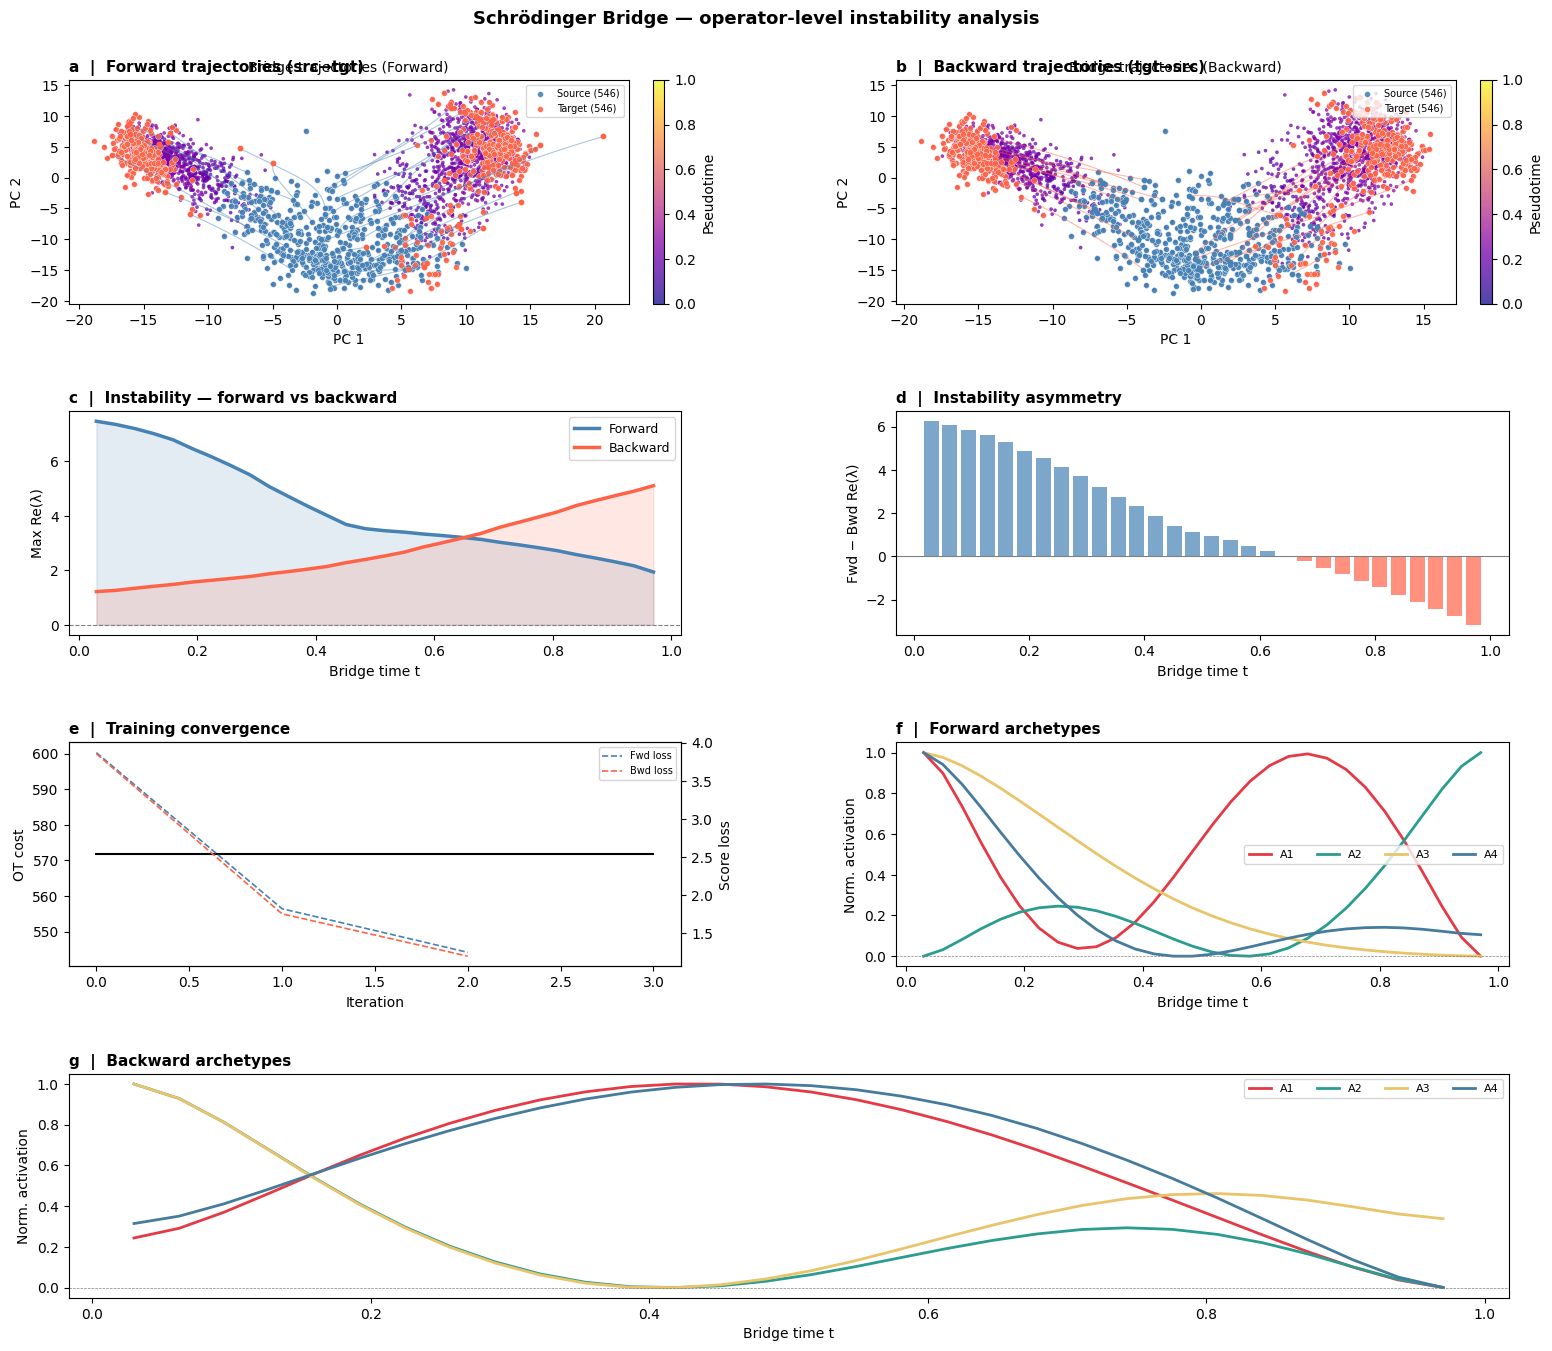

Forward-only  (23): Aqp1, Car1, Cd52, Cd74, Coro1a, Crip1, Cst3, Ctse, Cyba, H2-Aa, H2-Ab1, H2-Eb1
Backward-only (11): C3, Fcgr3, Hnrnph1, Malat1, Mt2, Napsa, P4hb, Ramp1, Slc25a4, Sphk1, Sun2
Shared        (17): Alas1, Arhgdib, Blvrb, Car2, Ctsg, Elane, Ermap, Fam132a, Gstm1, Hp, Klf1, Ly6c2
Saved: results/04_paul15_bridge/bridge_genes.pdf


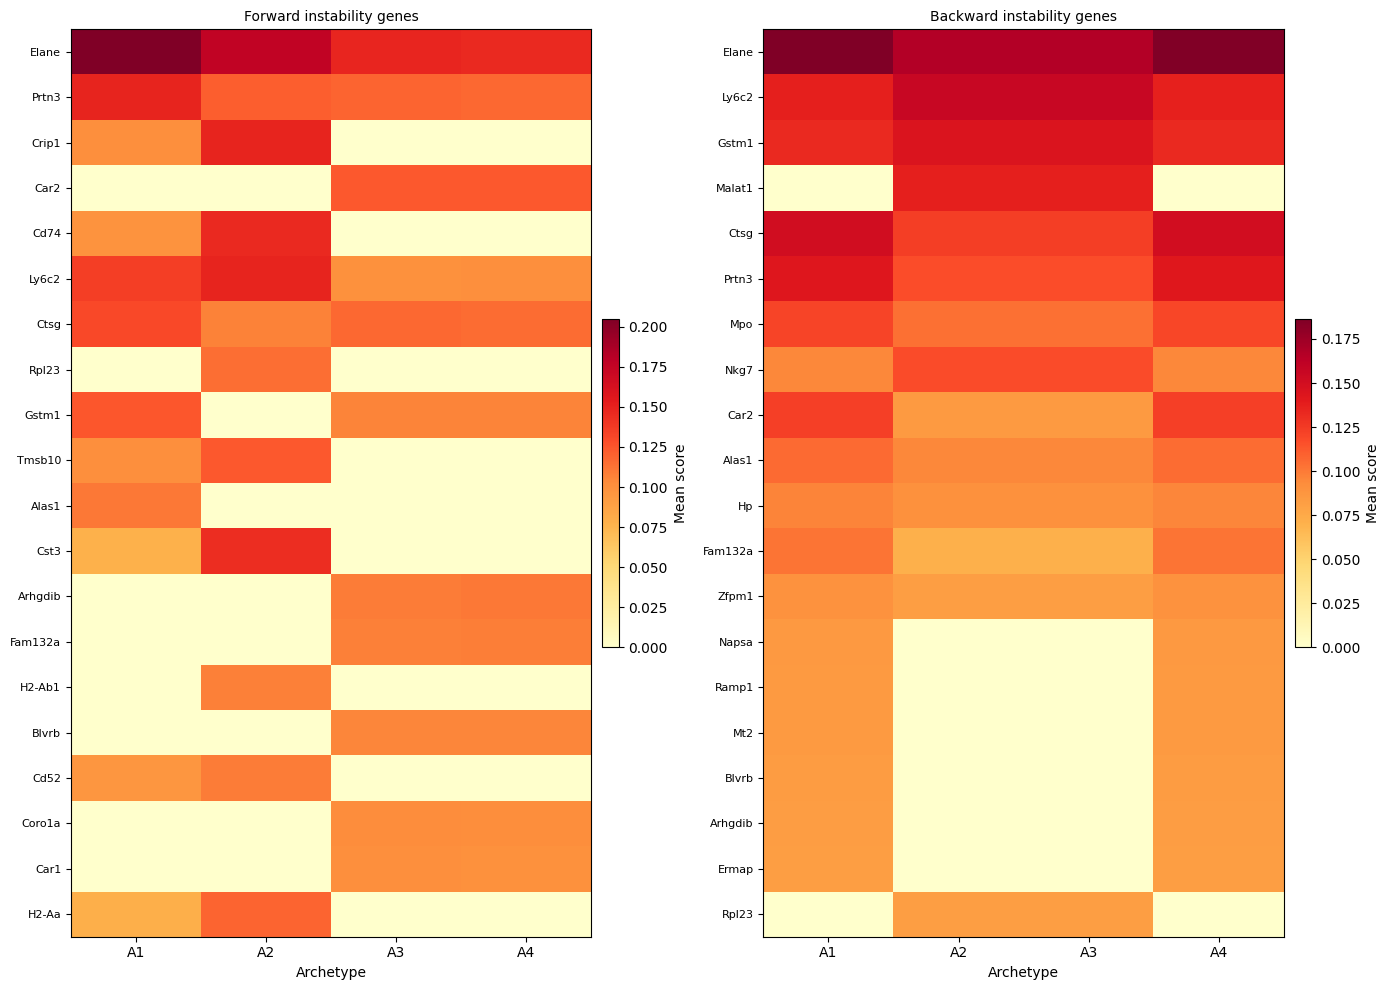

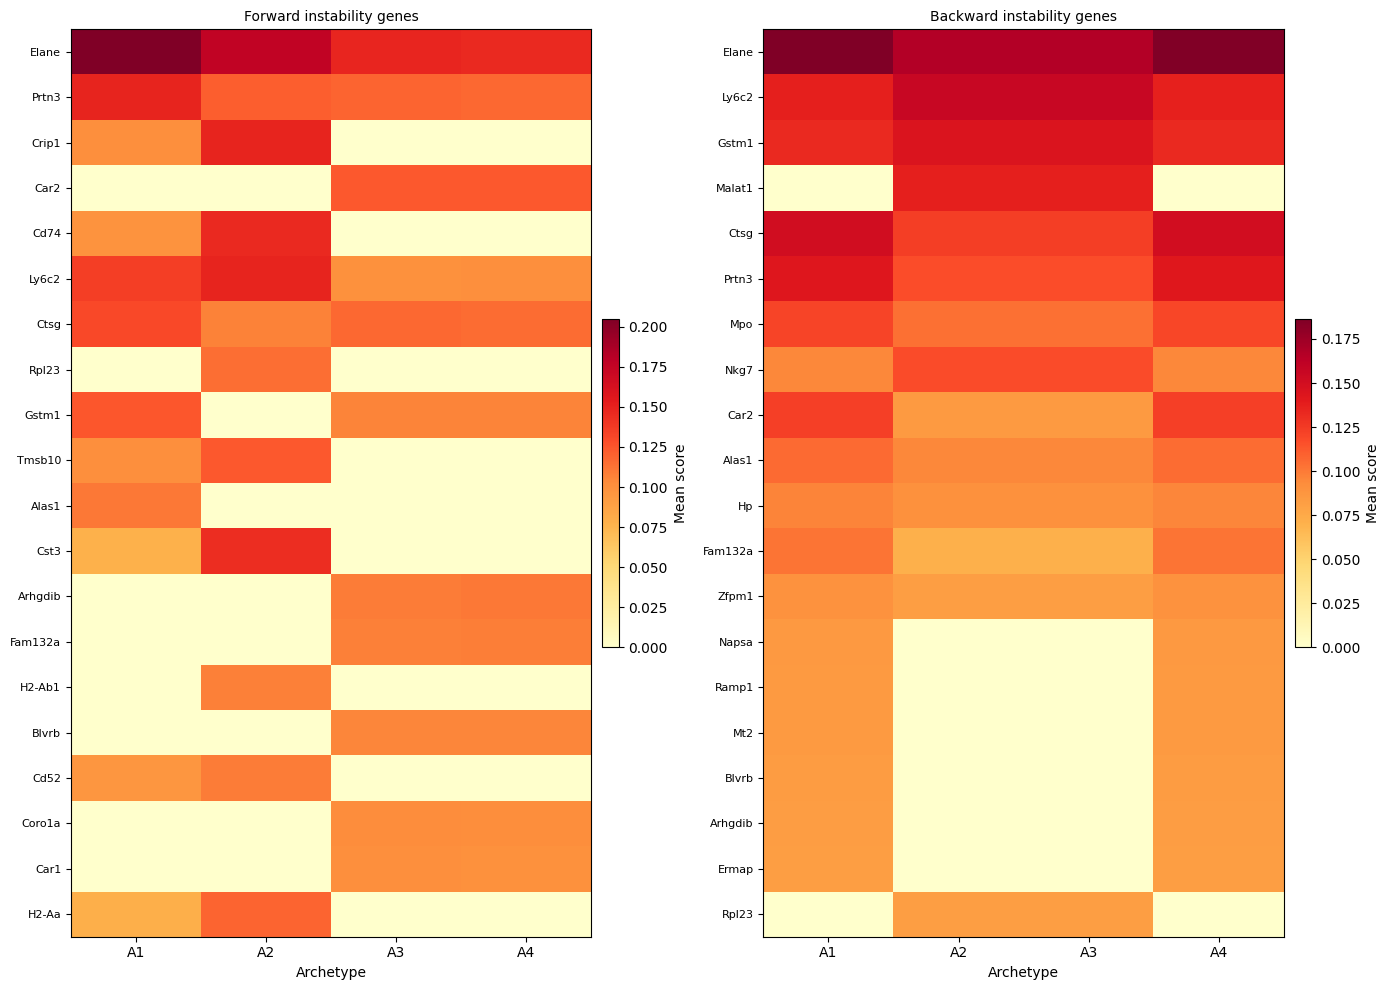

In [35]:
sjd.pl.bridge_summary(
    adata,
    basis = 'X_pca',
    save  = OUTDIR + 'bridge_summary.pdf',
)

sjd.pl.bridge_gene_comparison(
    adata,
    n_genes = 20,
    save    = OUTDIR + 'bridge_genes.pdf',
)

## Plot individual panels

Every panel in the summary figure is also available as a standalone call:

| Function | What it shows |
|----------|---------------|
| `sjd.pl.bridge_trajectories(adata)` | PCA + forward/backward paths |
| `sjd.pl.bridge_source_target(adata)` | Source vs target scatter only |
| `sjd.pl.bridge_instability(adata)` | Instability curves + asymmetry |
| `sjd.pl.bridge_archetypes(adata)` | Activation profiles both directions |
| `sjd.pl.bridge_genes(adata)` | Gene × archetype heatmaps |
| `sjd.pl.bridge_gene_comparison(adata)` | Heatmaps + forward/backward gene lists |

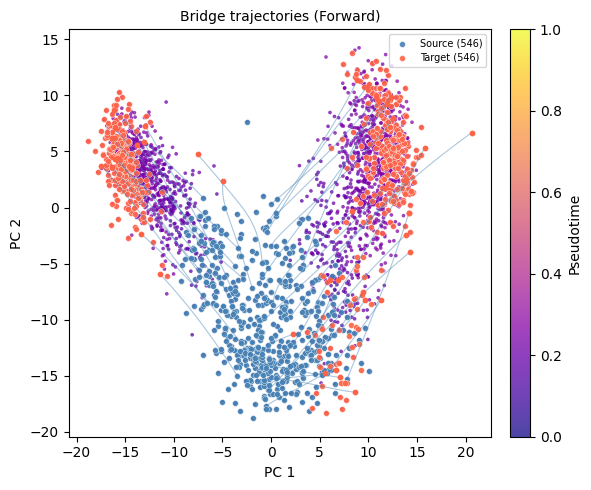

<Axes: title={'center': 'Bridge trajectories (Forward)'}, xlabel='PC 1', ylabel='PC 2'>

In [36]:
# PCA + trajectory paths (forward)
sjd.pl.bridge_trajectories(
    adata,
    direction = 'forward',
    color     = 'pseudotime',
    n_show    = 40,
    save      = OUTDIR + 'trajectories_forward.pdf',
)

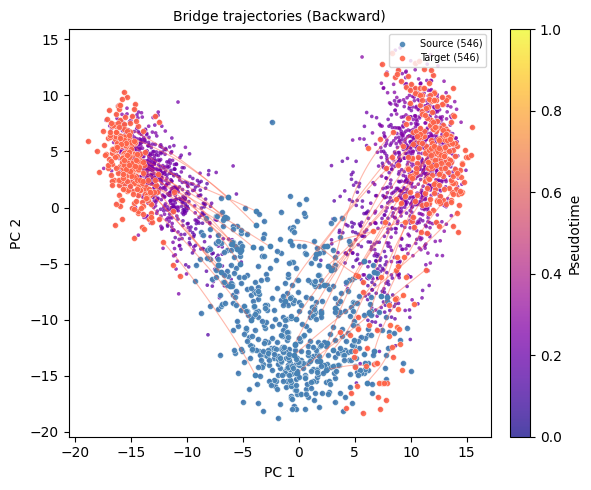

<Axes: title={'center': 'Bridge trajectories (Backward)'}, xlabel='PC 1', ylabel='PC 2'>

In [37]:
# PCA + trajectory paths (backward)
sjd.pl.bridge_trajectories(
    adata,
    direction = 'backward',
    color     = 'pseudotime',
    n_show    = 40,
    save      = OUTDIR + 'trajectories_backward.pdf',
)

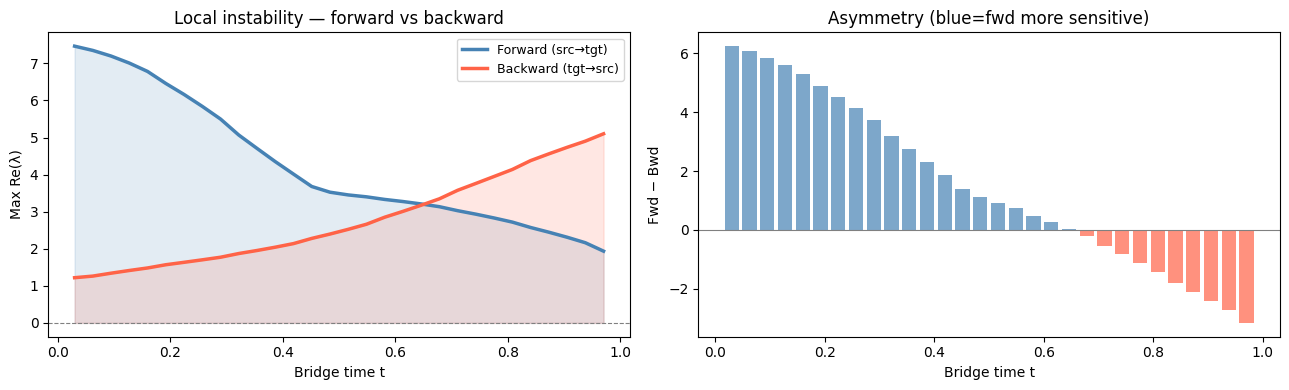

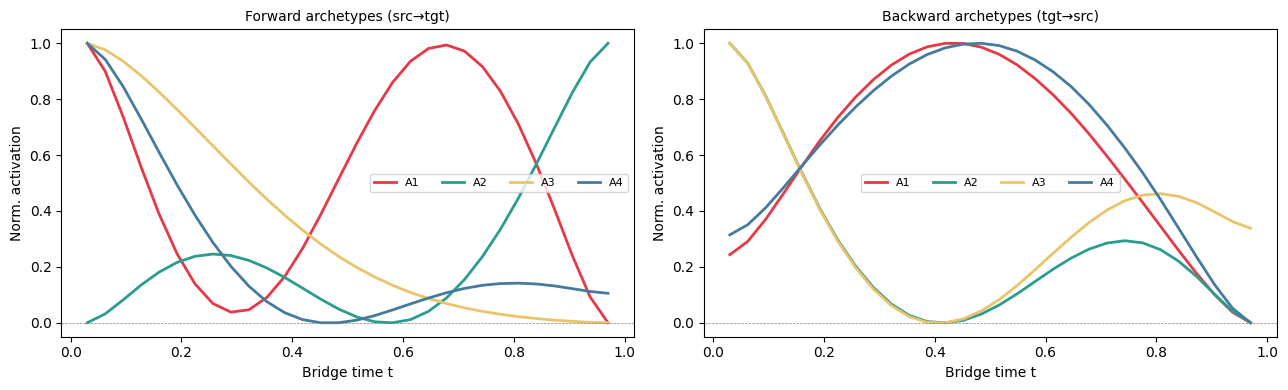

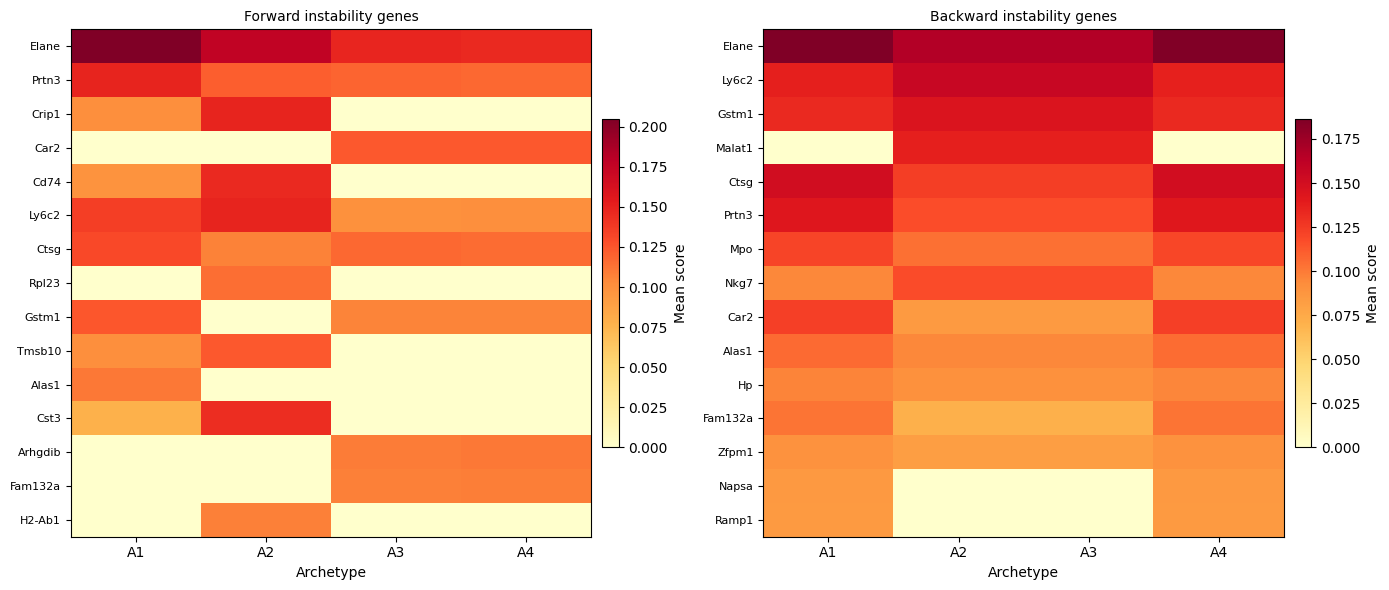

array([<Axes: title={'center': 'Forward instability genes'}, xlabel='Archetype'>,
       <Axes: title={'center': 'Backward instability genes'}, xlabel='Archetype'>],
      dtype=object)

In [38]:
# Instability curves + asymmetry bar chart
sjd.pl.bridge_instability(adata, save=OUTDIR + 'instability.pdf')

# Archetype activation profiles (forward and backward side by side)
sjd.pl.bridge_archetypes(adata, save=OUTDIR + 'archetypes.pdf')

# Gene heatmaps
sjd.pl.bridge_genes(adata, n_genes=15, save=OUTDIR + 'genes.pdf')

## Step 4 — Extract and save instability gene tables

In [48]:
df_fwd, df_bwd = sjd.tl.get_bridge_instability_genes(adata, n_genes=20)

df_fwd.to_csv(OUTDIR + 'instability_genes_forward.csv',  index=False)
df_bwd.to_csv(OUTDIR + 'instability_genes_backward.csv', index=False)

print('FORWARD instability genes (progenitor -> committed):')
for arch in df_fwd['archetype'].unique():
    sub = df_fwd[df_fwd['archetype'] == arch]
    genes = ', '.join(sub['gene'].tolist()[:20])
    print(f'  {arch} (peak t={sub["peak_t"].iloc[0]:.2f}): {genes}')

print()
print('BACKWARD instability genes (committed -> progenitor):')
for arch in df_bwd['archetype'].unique():
    sub = df_bwd[df_bwd['archetype'] == arch]
    genes = ', '.join(sub['gene'].tolist()[:20])
    print(f'  {arch} (peak t={sub["peak_t"].iloc[0]:.2f}): {genes}')

FORWARD instability genes (progenitor -> committed):
  A1 (peak t=0.42): Elane, Gstm1, Ctsg, Prtn3, Nkg7, Mpo, Ly6c2, Alas1, Sun2, Srgn, Car2, Hp, Arhgdib, Fam132a, Cd63, Fcgr3, Napsa, Pkm2, Pglyrp1, Hdc
  A2 (peak t=0.03): Elane, Prtn3, Ctsg, Ly6c2, Car2, Gstm1, Fam132a, Mpo, Arhgdib, Pkm2, Hp, Blvrb, Car1, Alas1, Mt2, Ramp1, Coro1a, Ermap, Nkg7, Ctse
  A3 (peak t=0.03): Elane, Gstm1, Srgn, Sun2, Arhgdib, Cd63, Prpf8, Prtn3, Nkg7, Prdx5, Fcgr3, Bat2d, Ctsg, Malat1, Alas1, Hdc, Ly6c2, 0610010K14Rik, Car2, Mt2
  A4 (peak t=0.45): Elane, Gstm1, Ctsg, Prtn3, Nkg7, Mpo, Ly6c2, Sun2, Alas1, Srgn, Car2, Cd63, Hp, Arhgdib, Fcgr3, Fam132a, Hdc, Pglyrp1, 1190002H23Rik, Prdx5

BACKWARD instability genes (committed -> progenitor):
  A1 (peak t=0.26): Elane, Ly6c2, Prtn3, Ctsg, Gstm1, Hp, Mpo, Mt2, Fam132a, Alas1, Coro1a, Nkg7, Car2, Ermap, Pkm2, Arhgdib, Blvrb, Ramp1, Sphk1, Napsa
  A2 (peak t=0.03): Elane, Ly6c2, Prtn3, Ctsg, Gstm1, Hp, Mt2, Mpo, Coro1a, Fam132a, Car2, Ermap, Alas1, Pkm2, Blvrb,

## Regulatory Network Inference — Forward & Backward

Links instability genes to upstream TF regulators using a signed TF-target network (CollecTRI → TRRUST → built-in). Scores each TF on six metrics:

| Metric | What it captures |
|--------|------------------|
| Weighted out-degree | Total instability explained by TF targets |
| Mean target instability | Quality: few sharp targets > many weak ones |
| Regulon enrichment | Hypergeometric overlap with top instability genes |
| Branch specificity | Entropy-based archetype preference |
| Database confidence | Mean edge weight in the source network |
| Pseudotime lead | TF expression peak before target instability peak |

**Figure 5 (hybrid network):** solid edges = database-confirmed links; dashed edges = de novo co-instability pairs inferred from Jacobian eigenvector structure.

In [40]:

# direction='both' scores forward and backward separately
df_reg_fwd = sjd.tl.infer_regulators(
    adata,
    key       = 'scjdo_bridge',
    direction = 'forward',
    organism  = 'mouse',
    n_top     = 20,
    key_added = 'scjdo_regulators_fwd',
)
df_reg_bwd = sjd.tl.infer_regulators(
    adata,
    key       = 'scjdo_bridge',
    direction = 'backward',
    organism  = 'mouse',
    n_top     = 20,
    key_added = 'scjdo_regulators_bwd',
)
df_reg_fwd.to_csv(OUTDIR + 'regulators_forward.csv', index=False)
df_reg_bwd.to_csv(OUTDIR + 'regulators_backward.csv', index=False)
print('Forward top 5:', df_reg_fwd['regulator'].head(5).tolist())
print('Backward top 5:', df_reg_bwd['regulator'].head(5).tolist())

[network] TRRUST v2 loaded — 7,057 edges
[forward] Scoring regulators against 2000 genes...
  Top 5: Sp1, Spi1, Nfkb1, Trp53, Jun
  De novo edges: 421
[network] TRRUST v2 loaded — 7,057 edges
[backward] Scoring regulators against 2000 genes...
  Top 5: Sp1, Nfkb1, Trp53, Spi1, Jun
  De novo edges: 345
Forward top 5: ['Sp1', 'Spi1', 'Nfkb1', 'Trp53', 'Jun']
Backward top 5: ['Sp1', 'Nfkb1', 'Trp53', 'Spi1', 'Jun']


Saved: results/04_paul15_bridge/regulator_summary_forward.pdf


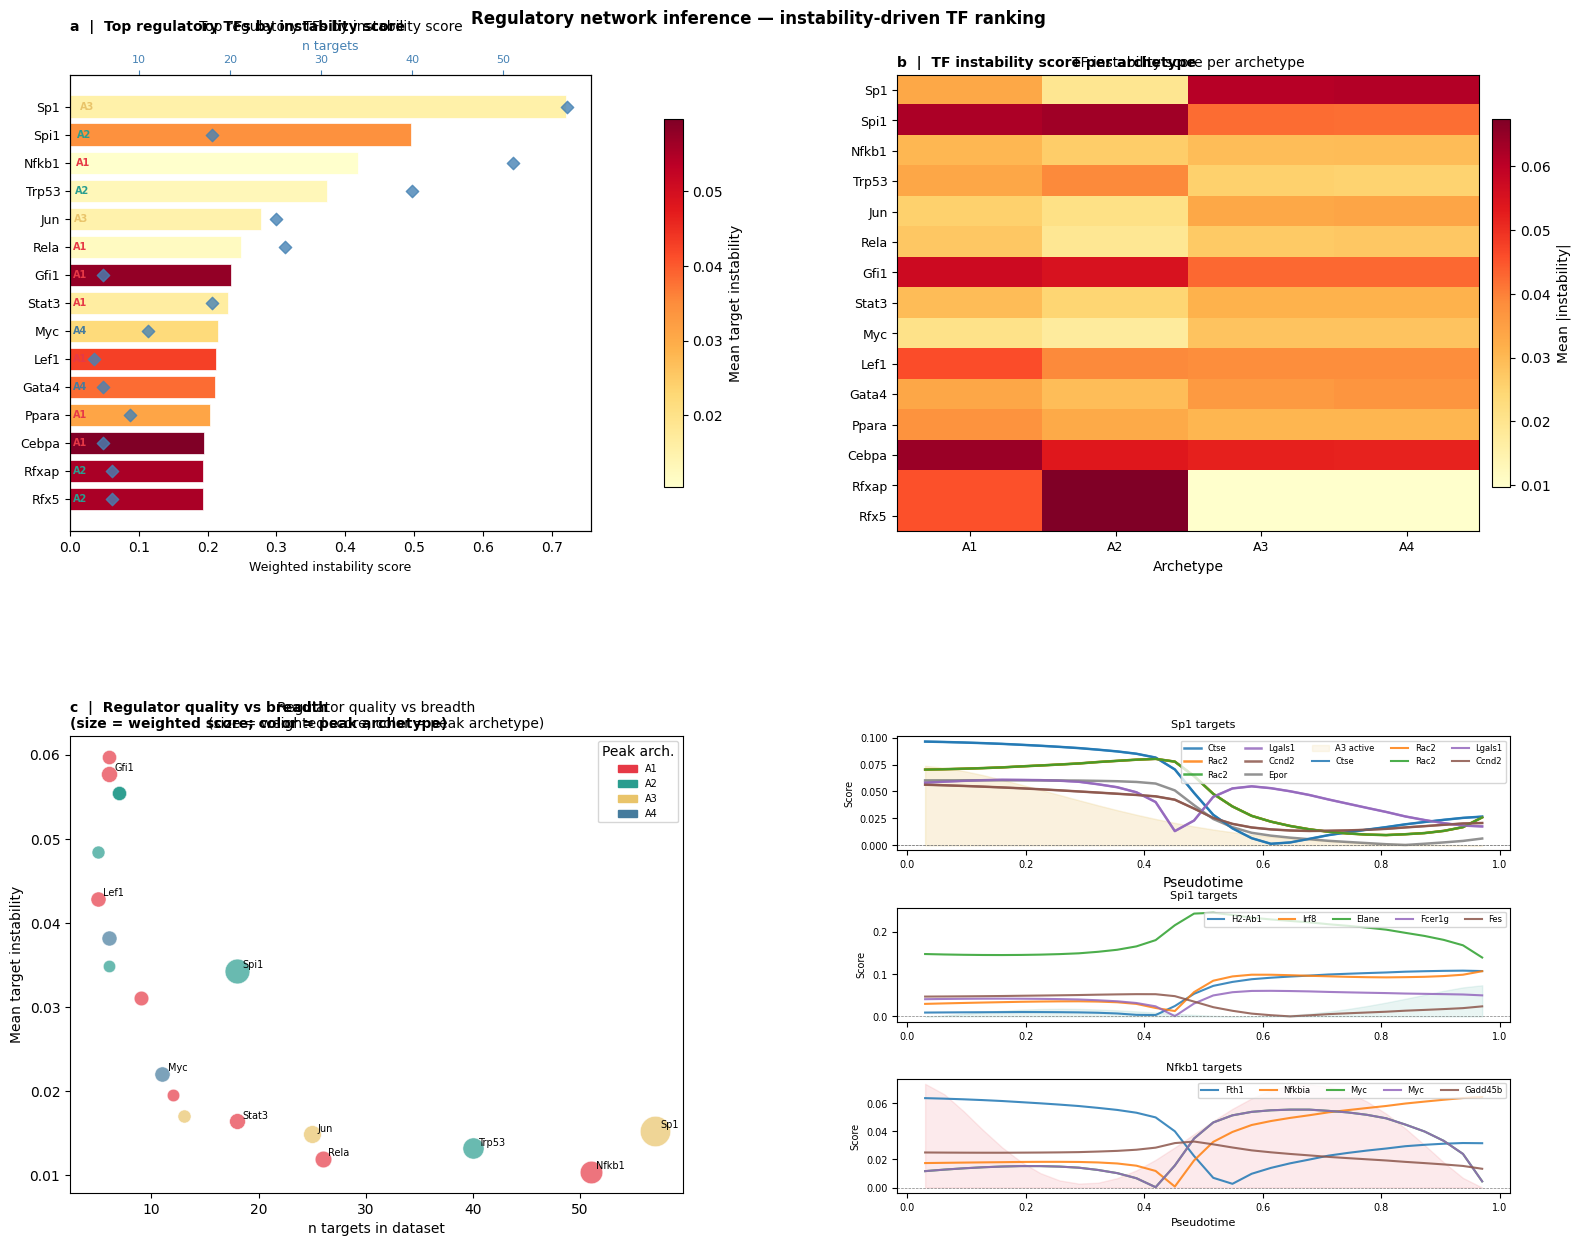

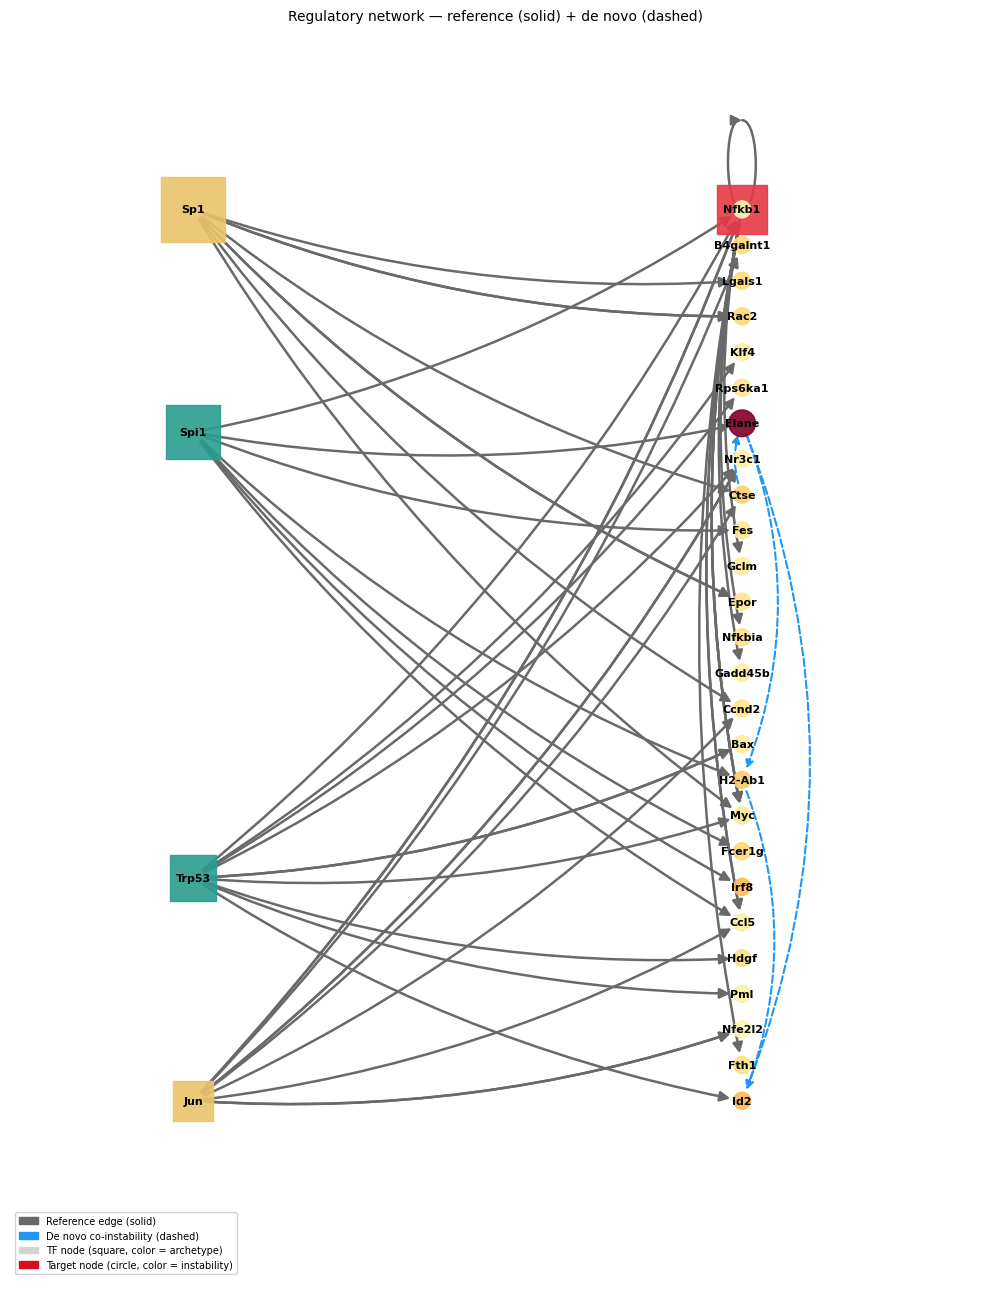

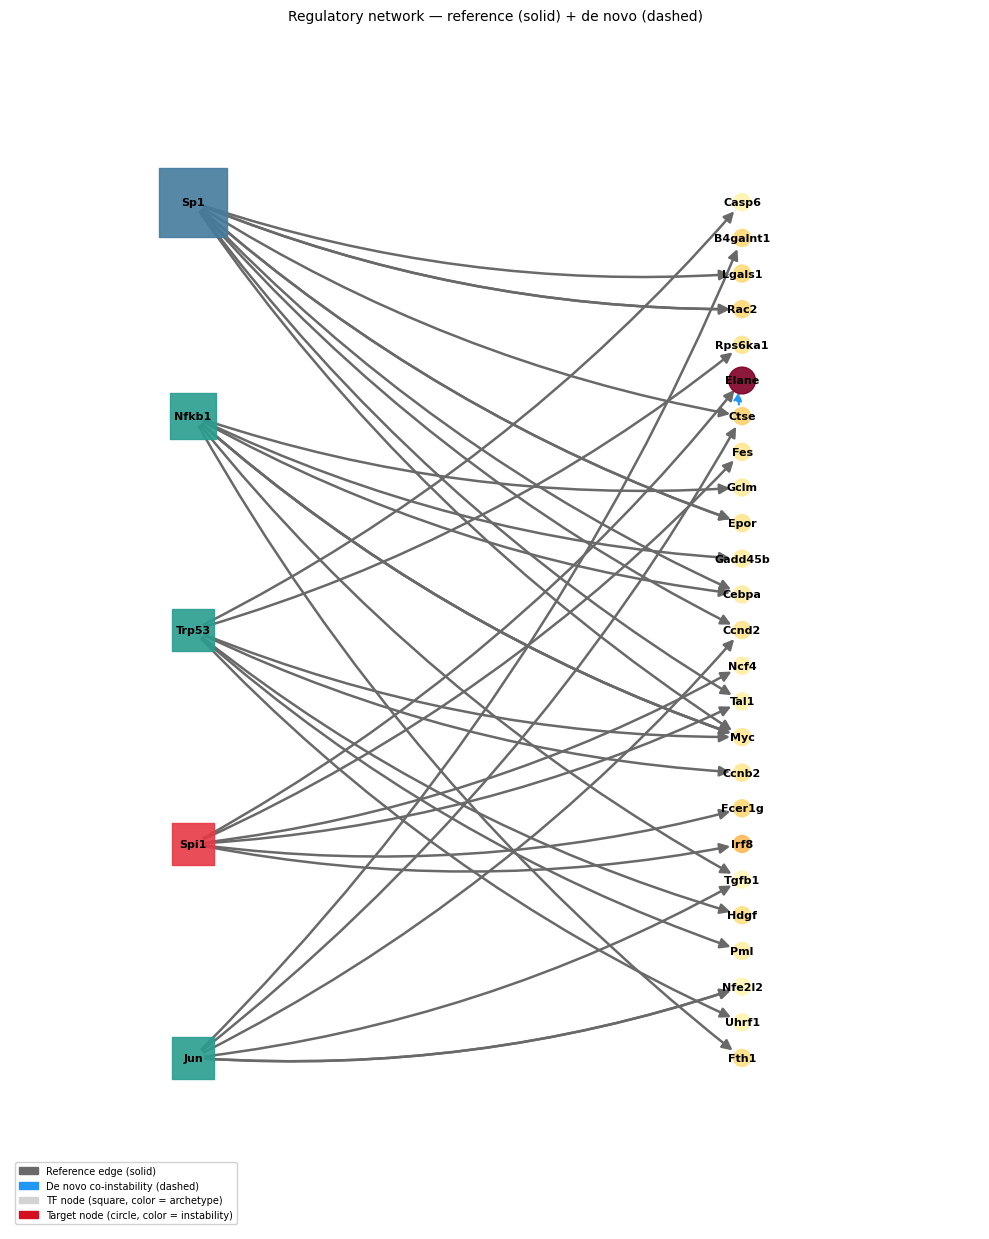

<Axes: title={'center': 'Regulatory network — reference (solid) + de novo (dashed)'}>

In [41]:
# Forward regulators
sjd.pl.regulator_summary(adata, key='scjdo_regulators_fwd',
                          scjdo_key='scjdo_bridge',
                          save=OUTDIR + 'regulator_summary_forward.pdf')
sjd.pl.regulator_network(adata, key='scjdo_regulators_fwd',
                          scjdo_key='scjdo_bridge',
                          n_tfs=5, n_targets=6,
                          save=OUTDIR + 'regulator_network_forward.pdf')

# Backward regulators
sjd.pl.regulator_network(adata, key='scjdo_regulators_bwd',
                          scjdo_key='scjdo_bridge',
                          direction='backward',
                          n_tfs=5, n_targets=6,
                          save=OUTDIR + 'regulator_network_backward.pdf')

In [43]:
adata

AnnData object with n_obs × n_vars = 2730 × 2000
    obs: 'paul15_clusters', 'dpt_pseudotime', 'pseudotime'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'iroot', 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'diffmap_evals', 'scjdo_bridge', 'scjdo_regulators_fwd', 'scjdo_regulators_bwd'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [44]:
fw_data = adata.copy()
fw_data.uns['scjdo_regulators'] = fw_data.uns['scjdo_regulators_fwd']

rv_data = adata.copy()
rv_data.uns['scjdo_regulators'] = rv_data.uns['scjdo_regulators_bwd']

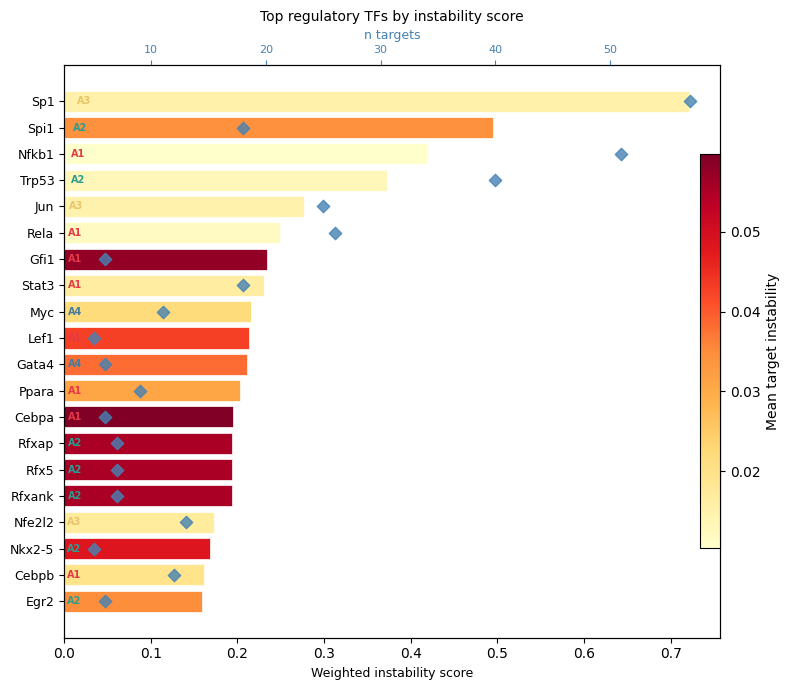

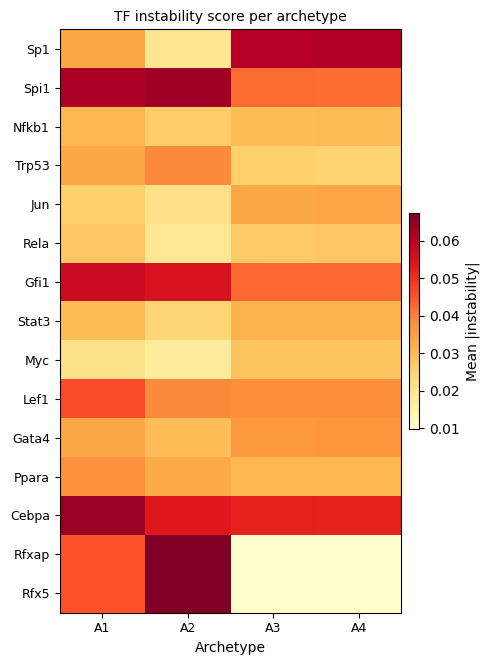

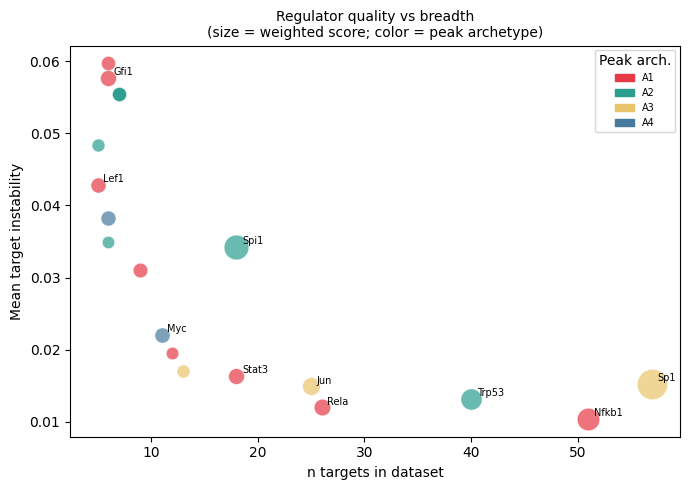

/Users/terooatt/Downloads/scJDO/scjdo/pl/_regulators.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


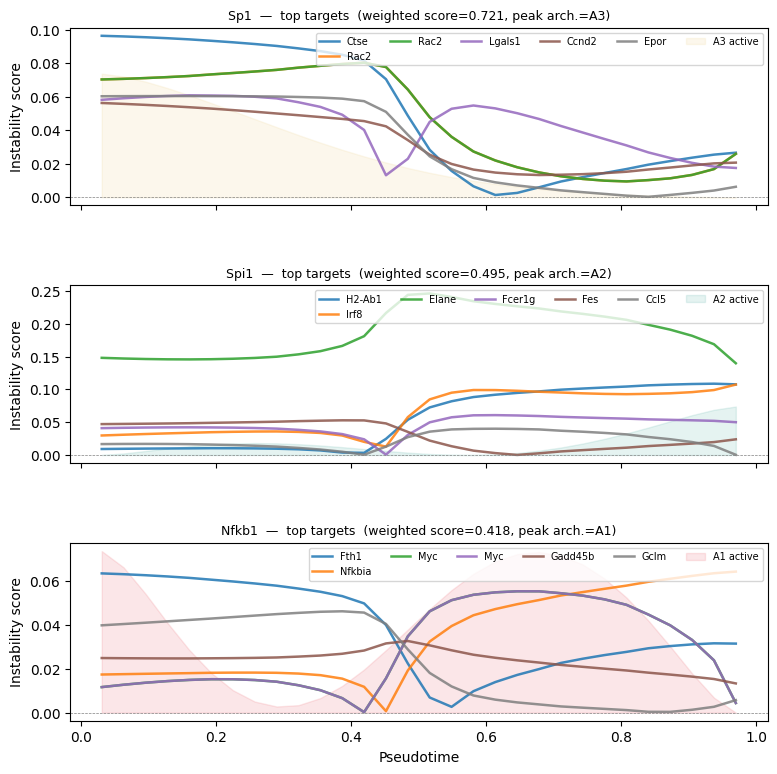

array([<Axes: title={'center': 'Sp1  —  top targets  (weighted score=0.721, peak arch.=A3)'}, ylabel='Instability score'>,
       <Axes: title={'center': 'Spi1  —  top targets  (weighted score=0.495, peak arch.=A2)'}, ylabel='Instability score'>,
       <Axes: title={'center': 'Nfkb1  —  top targets  (weighted score=0.418, peak arch.=A1)'}, xlabel='Pseudotime', ylabel='Instability score'>],
      dtype=object)

In [45]:
# Individual panels
sjd.pl.regulator_barplot(fw_data, n_show=20, save=OUTDIR + 'reg_barplot.pdf')
sjd.pl.regulator_heatmap(fw_data, n_show=15, save=OUTDIR + 'reg_heatmap.pdf')
sjd.pl.regulator_scatter(fw_data, n_label=10, save=OUTDIR + 'reg_scatter.pdf')
sjd.pl.regulator_profiles(fw_data, n_tfs=3,  save=OUTDIR + 'reg_profiles.pdf')

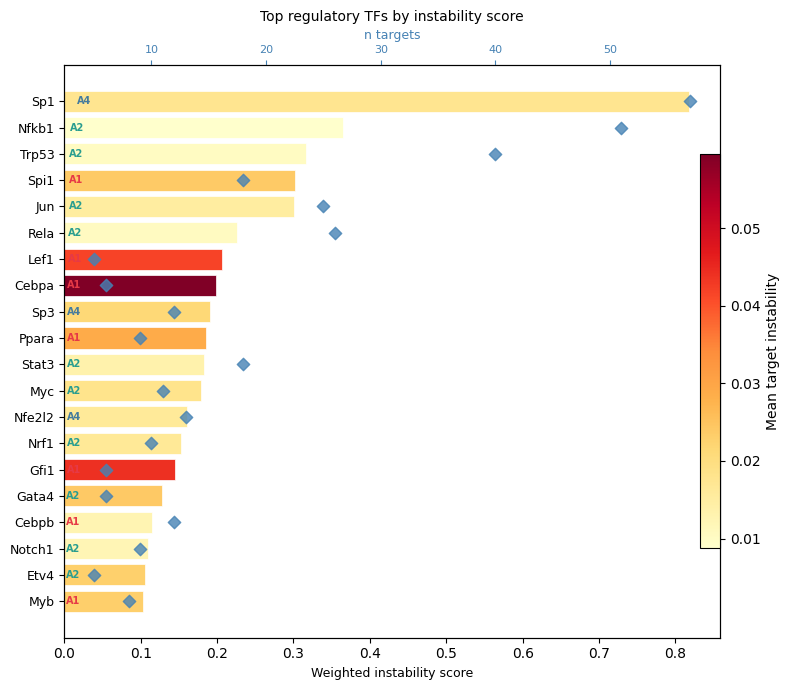

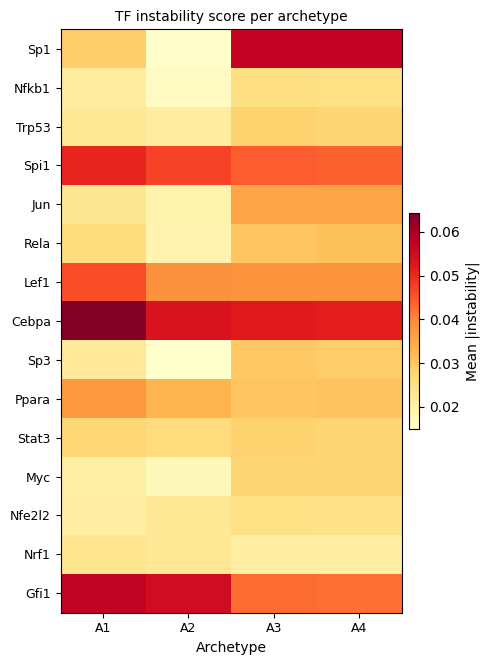

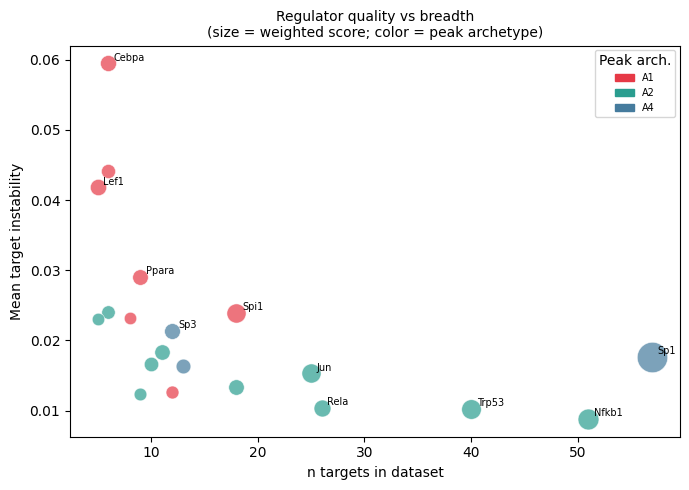

/Users/terooatt/Downloads/scJDO/scjdo/pl/_regulators.py:328: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


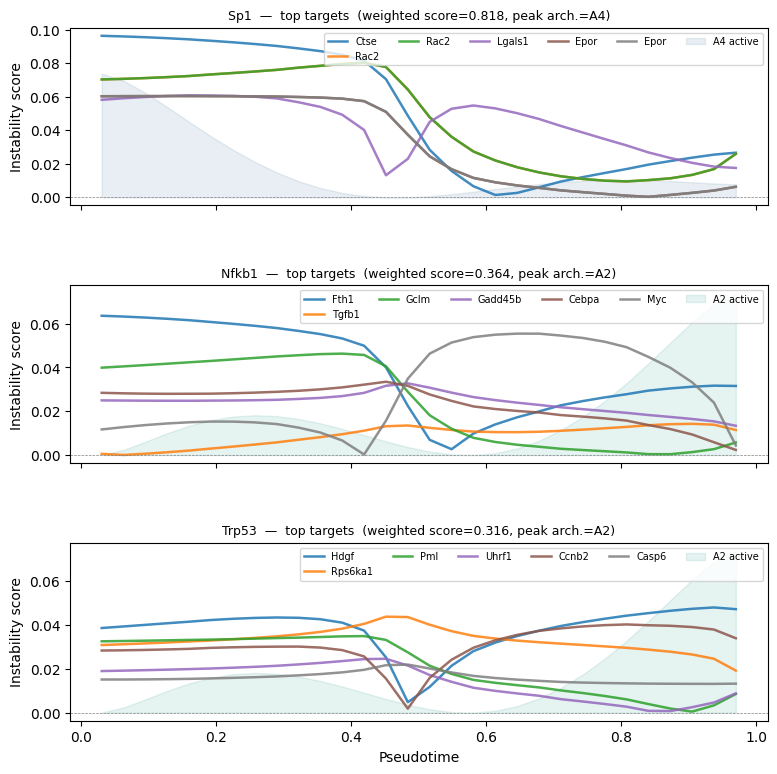

array([<Axes: title={'center': 'Sp1  —  top targets  (weighted score=0.818, peak arch.=A4)'}, ylabel='Instability score'>,
       <Axes: title={'center': 'Nfkb1  —  top targets  (weighted score=0.364, peak arch.=A2)'}, ylabel='Instability score'>,
       <Axes: title={'center': 'Trp53  —  top targets  (weighted score=0.316, peak arch.=A2)'}, xlabel='Pseudotime', ylabel='Instability score'>],
      dtype=object)

In [46]:
# Individual panels
sjd.pl.regulator_barplot(rv_data, n_show=20, save=OUTDIR + 'reg_barplot.pdf')
sjd.pl.regulator_heatmap(rv_data, n_show=15, save=OUTDIR + 'reg_heatmap.pdf')
sjd.pl.regulator_scatter(rv_data, n_label=10, save=OUTDIR + 'reg_scatter.pdf')
sjd.pl.regulator_profiles(rv_data, n_tfs=3,  save=OUTDIR + 'reg_profiles.pdf')